In [21]:
import pandas as pd

# Load dataset
data = pd.read_csv("ghana_weather_final.csv")

# Preview
data.head(20)

,Year,Month,Month_Num,Rainfall_mm,Avg_Temp,Max_Temp
0,2010,Jan,1,57.21,20.24,22.32
1,2010,Feb,2,39.97,19.95,22.30
2,2010,Mar,3,20.55,19.75,21.41
3,2010,Apr,4,23.36,20.10,21.67
4,2010,May,5,2.99,20.18,21.64
5,2010,Jun,6,1.33,21.13,21.84
6,2010,Jul,7,0.78,22.02,23.06
7,2010,Aug,8,2.22,23.21,24.26
8,2010,Sep,9,48.86,23.70,24.48
9,2010,Oct,10,3.88,23.47,24.89


In [ ]:
# Sorting properly
data = data.sort_values(by=['Year', 'Month_Num'])

# Create lag (previous month's rainfall)
data['Rainfall_Lag1'] = data['Rainfall_mm'].shift(1)

# Drop first row (lag is NaN)
data = data.dropna()

data.head(20)

,Year,Month,Month_Num,Rainfall_mm,Avg_Temp,Max_Temp,Rainfall_Lag1
2,2010,Mar,3,20.55,19.75,21.41,39.97
3,2010,Apr,4,23.36,20.10,21.67,20.55
4,2010,May,5,2.99,20.18,21.64,23.36
5,2010,Jun,6,1.33,21.13,21.84,2.99
6,2010,Jul,7,0.78,22.02,23.06,1.33
7,2010,Aug,8,2.22,23.21,24.26,0.78
8,2010,Sep,9,48.86,23.70,24.48,2.22
9,2010,Oct,10,3.88,23.47,24.89,48.86
10,2010,Nov,11,70.53,22.40,23.59,3.88
11,2010,Dec,12,33.69,21.16,23.80,70.53


In [ ]:

# TRAINING MODEL WITH LAG
# ---------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Features
X = data[['Avg_Temp', 'Month_Num', 'Year', 'Rainfall_Lag1']]

# Target
y = data['Rainfall_mm']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.07787310409978065
RMSE: 13.767019124254983


In [ ]:
# CREATING 2040 DATA


future_2040 = pd.DataFrame({
    'Year': [2040]*12,
    'Month_Num': list(range(1, 13))
})

In [ ]:
future_2040.head(10)

,Year,Month_Num
0,2040,1
1,2040,2
2,2040,3
3,2040,4
4,2040,5
5,2040,6
6,2040,7
7,2040,8
8,2040,9
9,2040,10


In [ ]:
# Monthly average temperature
monthly_temp_avg = data.groupby('Month_Num')['Avg_Temp'].mean().reset_index()

future_2040 = future_2040.merge(monthly_temp_avg, on='Month_Num', how='left')

In [ ]:
future_2040['Rainfall_Lag1'] = 0
future_2040['Predicted_Rainfall'] = 0

In [ ]:
# RECURSIVE PREDICTION FOR 2040


for i in range(len(future_2040)):

    # January → use last real rainfall from dataset
    if i == 0:
        last_rainfall = data.iloc[-1]['Rainfall_mm']
        future_2040.loc[i, 'Rainfall_Lag1'] = last_rainfall
    else:
        # Use previous predicted rainfall
        future_2040.loc[i, 'Rainfall_Lag1'] = future_2040.loc[i-1, 'Predicted_Rainfall']

    # Prepare input
    X_future = future_2040.loc[i, ['Avg_Temp', 'Month_Num', 'Year', 'Rainfall_Lag1']].values.reshape(1, -1)

    # Predict
    prediction = model.predict(X_future)

    # Store result
    future_2040.loc[i, 'Predicted_Rainfall'] = prediction[0]

future_2040

/tmp/ipykernel_21011/3797080678.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25.42' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  future_2040.loc[i, 'Rainfall_Lag1'] = last_rainfall
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipykernel_21011/3797080678.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.537379120990806' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  future_2040.loc[i, 'Predicted_Rainfall'] = prediction[0]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with

,Year,Month_Num,Avg_Temp,Rainfall_Lag1,Predicted_Rainfall
0,2040,1,19.812857,25.420000,6.537379
1,2040,2,19.184667,6.537379,1.326007
2,2040,3,19.040000,1.326007,0.433949
3,2040,4,19.568667,0.433949,0.976703
4,2040,5,20.358667,0.976703,2.001157
5,2040,6,21.591333,2.001157,3.235166
6,2040,7,22.650667,3.235166,4.511021
7,2040,8,23.695333,4.511021,5.797921
8,2040,9,24.069333,5.797921,6.997866
9,2040,10,23.581333,6.997866,8.054572


In [ ]:
future_2040.head(12)

,Year,Month_Num,Avg_Temp,Rainfall_Lag1,Predicted_Rainfall
0,2040,1,19.812857,25.420000,6.537379
1,2040,2,19.184667,6.537379,1.326007
2,2040,3,19.040000,1.326007,0.433949
3,2040,4,19.568667,0.433949,0.976703
4,2040,5,20.358667,0.976703,2.001157
5,2040,6,21.591333,2.001157,3.235166
6,2040,7,22.650667,3.235166,4.511021
7,2040,8,23.695333,4.511021,5.797921
8,2040,9,24.069333,5.797921,6.997866
9,2040,10,23.581333,6.997866,8.054572


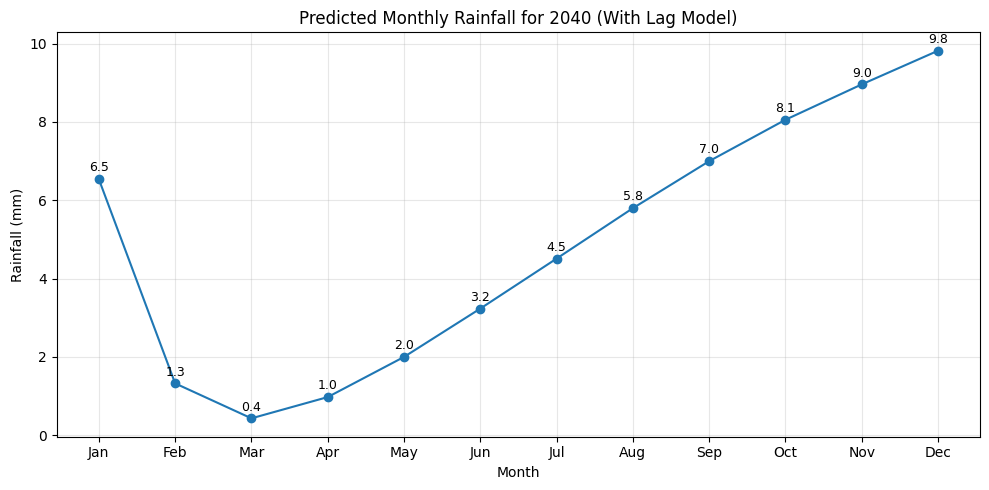

In [ ]:
import matplotlib.pyplot as plt

# Month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10,5))

# Ploting line chart
plt.plot(future_2040['Month_Num'], future_2040['Predicted_Rainfall'],
         marker='o')

# Adding data labels
for i, value in enumerate(future_2040['Predicted_Rainfall']):
    plt.text(future_2040['Month_Num'][i], value + 0.2,  # slight offset
             f"{value:.1f}", ha='center', fontsize=9)

# Titles and labels
plt.title("Predicted Monthly Rainfall for 2040 (With Lag Model)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

# Month names instead of numbers
plt.xticks(range(1, 13), month_labels)

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()